1

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

2

In [4]:
PROJECT_ROOT = Path(r"C:\Users\maria\Desktop\EEG-special-course")
PROCESSED_ROOT = PROJECT_ROOT / "data_processed"

manifest = pd.read_csv(PROCESSED_ROOT / "manifest_pre_ses1.csv")
manifest.head()

,participant_id,age,eyes_closed_file,eyes_open_file
0,sub-001,60,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
1,sub-002,67,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
2,sub-003,44,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
3,sub-004,24,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
4,sub-005,48,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...


3

In [5]:
example_row = manifest.iloc[0]

participant_id = example_row["participant_id"]
ec_file = example_row["eyes_closed_file"]
eo_file = example_row["eyes_open_file"]

print("Participant:", participant_id)
print("EyesClosed file:", ec_file)
print("EyesOpen file:", eo_file)

Participant: sub-001
EyesClosed file: C:\Users\maria\Desktop\EEG-special-course\data\ds005385\sub-001\ses-1\eeg\sub-001_ses-1_task-EyesClosed_acq-pre_eeg.edf
EyesOpen file: C:\Users\maria\Desktop\EEG-special-course\data\ds005385\sub-001\ses-1\eeg\sub-001_ses-1_task-EyesOpen_acq-pre_eeg.edf


4

In [6]:
def load_raw_eeg(edf_path):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")
    raw.pick("eeg")
    return raw

5

In [7]:
raw_ec = load_raw_eeg(ec_file)
raw_ec

<RawEDF | sub-001_ses-1_task-EyesClosed_acq-pre_eeg.edf, 64 x 184000 (184.0 s), ~89.9 MiB, data loaded>

6

In [9]:
raw_ec.ch_names[:20]
channel = "Oz"

7

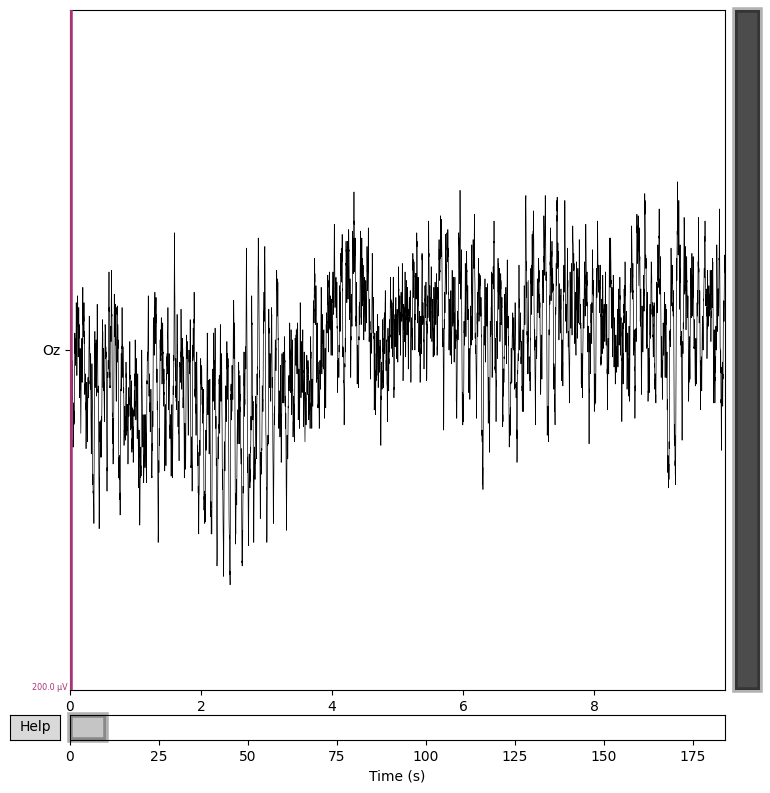

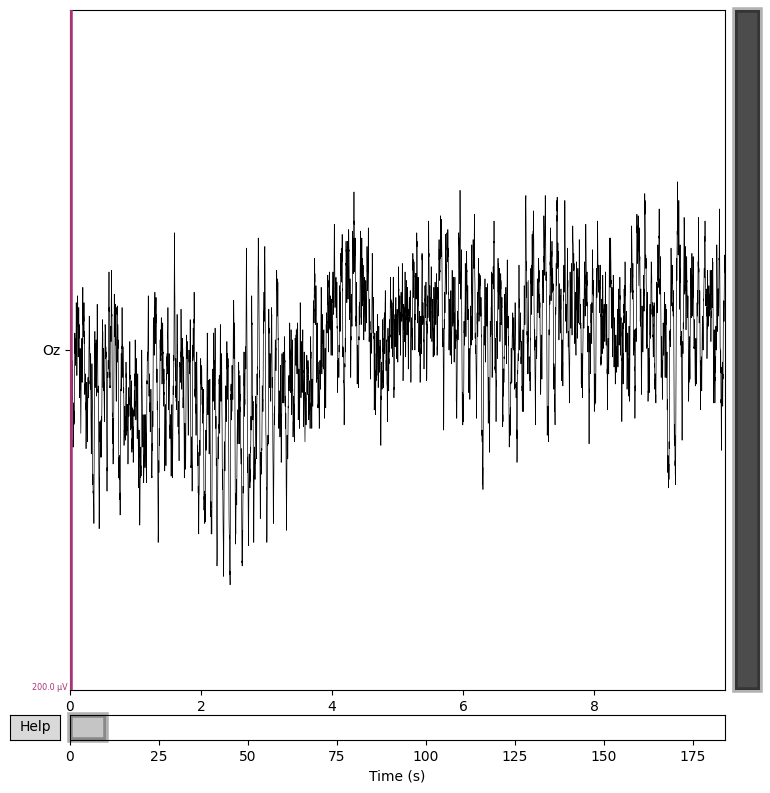

In [14]:
scaling_uv = 100e-6  # 100 microvolts
raw_ec.copy().pick([channel]).plot(
    duration=10,
    scalings={"eeg": scaling_uv},
    title=f"{participant_id} EyesClosed - RAW - {channel}"
)

8

In [12]:
raw_ec_filt = raw_ec.copy()

# 1–40 Hz band-pass
raw_ec_filt.filter(1.0, 40.0, verbose="ERROR")

# 50 Hz notch
raw_ec_filt.notch_filter(freqs=[50.0], verbose="ERROR")

raw_ec_filt

<RawEDF | sub-001_ses-1_task-EyesClosed_acq-pre_eeg.edf, 64 x 184000 (184.0 s), ~89.9 MiB, data loaded>

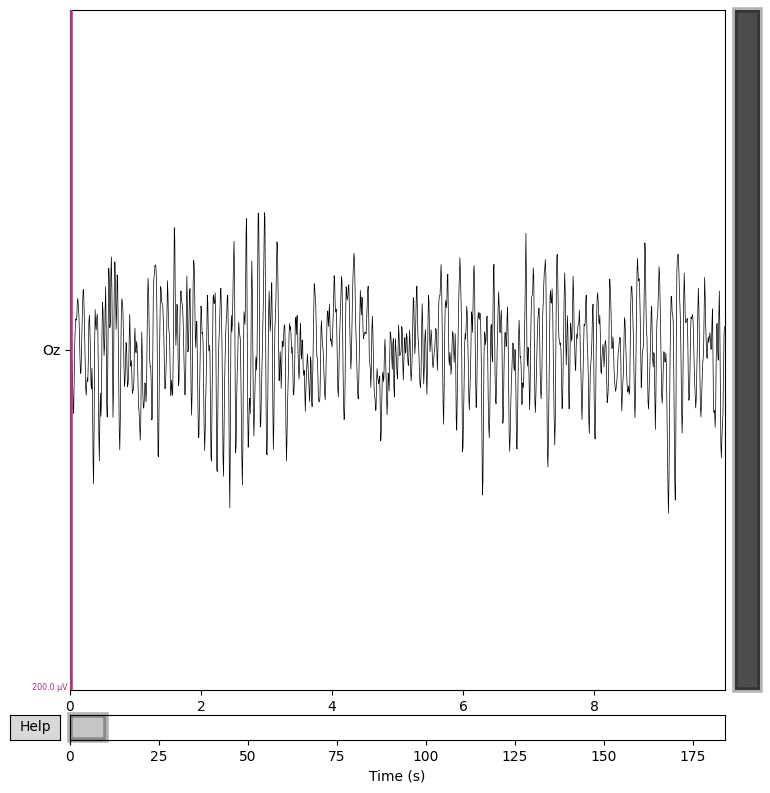

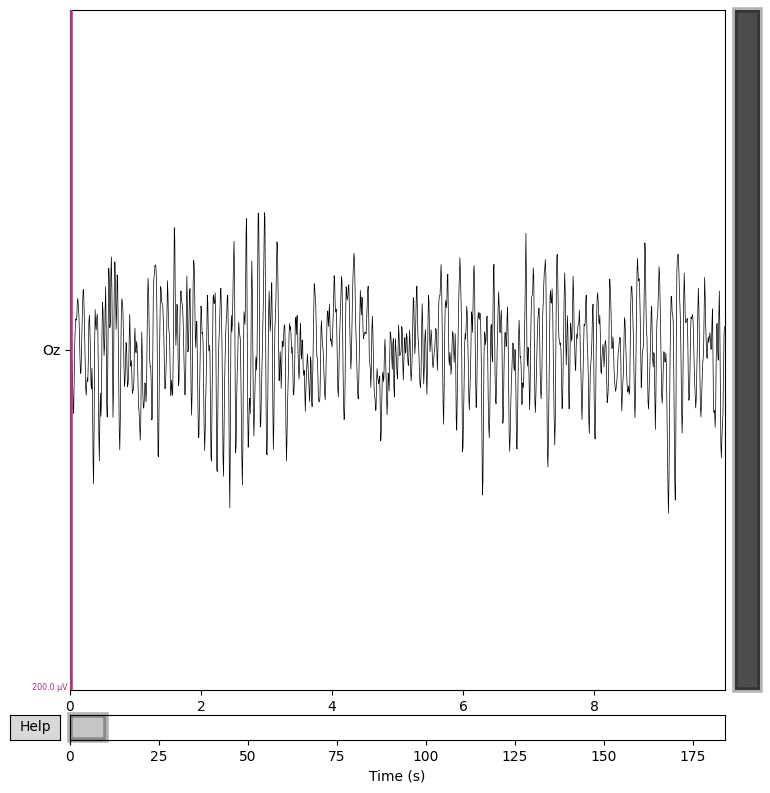

In [15]:
raw_ec_filt.copy().pick([channel]).plot(
    duration=10,
    scalings={"eeg": scaling_uv},
    title=f"{participant_id} EyesClosed - FILTERED (1–40 Hz + 50 Hz notch) - {channel}"
)

In [16]:
def plot_time_series_segment(raw, channel="Oz", start=0, duration=10, title=""):
    raw_ch = raw.copy().pick([channel])
    sfreq = raw_ch.info["sfreq"]
    data = raw_ch.get_data()[0]
    times = raw_ch.times

    mask = (times >= start) & (times <= start + duration)

    plt.figure(figsize=(10, 3))
    plt.plot(times[mask], data[mask])
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (V)")
    plt.title(title)
    plt.show()

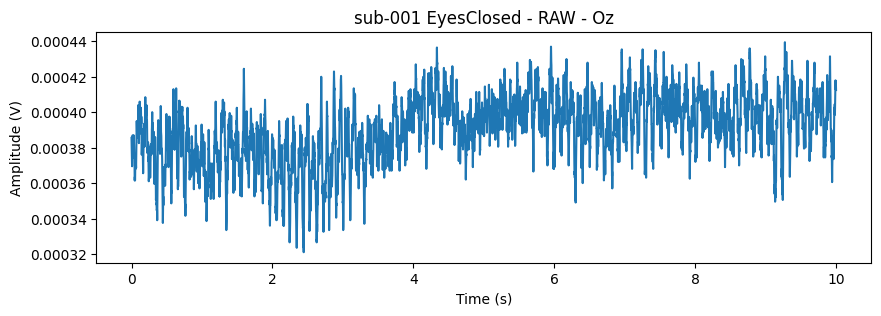

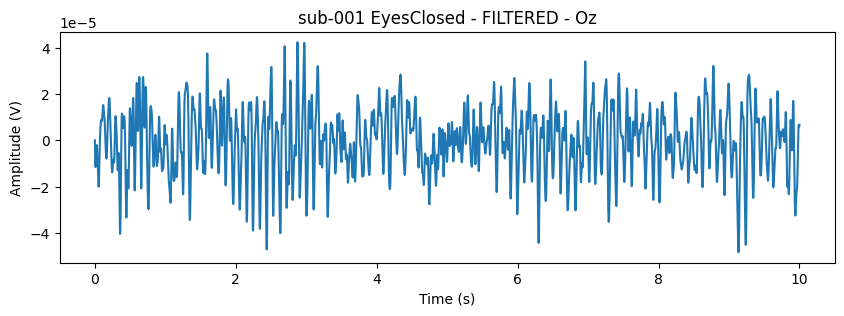

In [17]:
plot_time_series_segment(
    raw_ec,
    channel="Oz",
    start=0,
    duration=10,
    title=f"{participant_id} EyesClosed - RAW - Oz"
)

plot_time_series_segment(
    raw_ec_filt,
    channel="Oz",
    start=0,
    duration=10,
    title=f"{participant_id} EyesClosed - FILTERED - Oz"
)

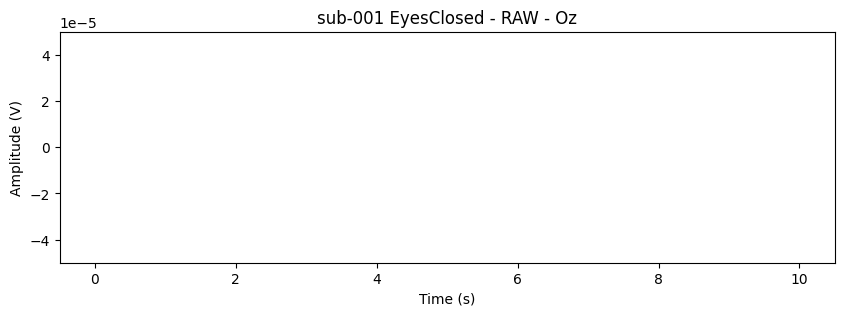

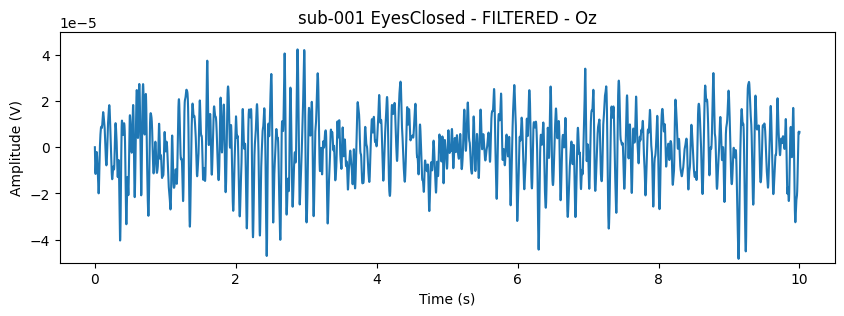

In [20]:
raw_ch = raw_ec.copy().pick([channel])
data_raw = raw_ch.get_data()[0]
times_raw = raw_ch.times

raw_ch_filt = raw_ec_filt.copy().pick([channel])
data_filt = raw_ch_filt.get_data()[0]
times_filt = raw_ch_filt.times

ylim = (-5e-5, 5e-5)
mask_raw = (times_raw >= 0) & (times_raw <= 10)
mask_filt = (times_filt >= 0) & (times_filt <= 10)

plt.figure(figsize=(10, 3))
plt.plot(times_raw[mask_raw], data_raw[mask_raw])
plt.ylim(ylim)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.title(f"{participant_id} EyesClosed - RAW - {channel}")
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(times_filt[mask_filt], data_filt[mask_filt])
plt.ylim(ylim)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.title(f"{participant_id} EyesClosed - FILTERED - {channel}")
plt.show()